## Posters for the Weizenbaum Center workshop

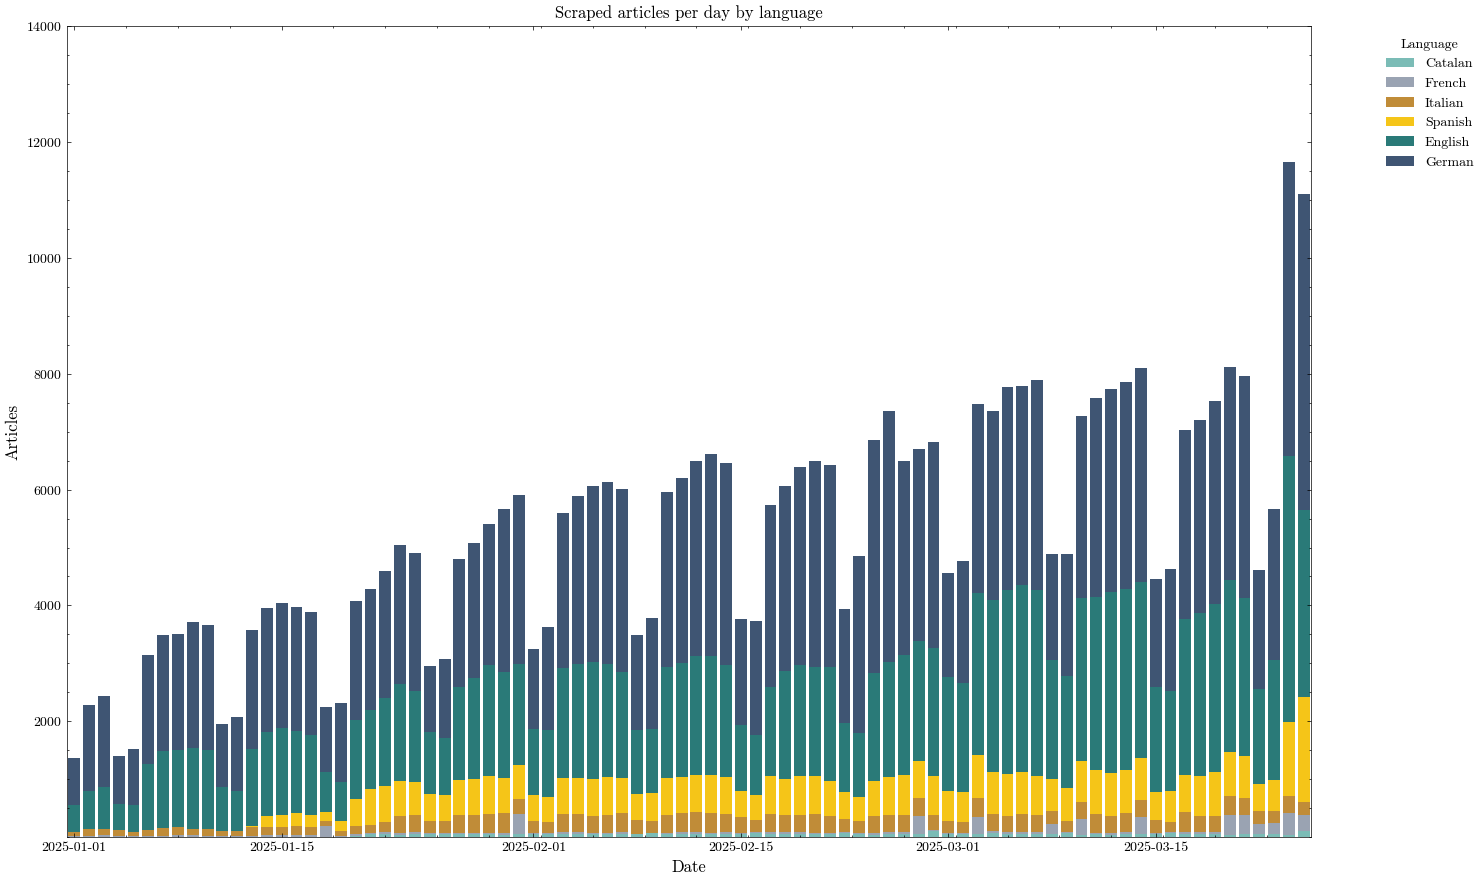

In [2]:
## desired colors
# Hauptfarbe (Main color):

# Dark blue/slate: #3F5573

# Akzentfarben (Accent colors):

# Teal: #2A7A78
# Yellow: #F5C518
# Gold/Brown: #C08C38

# Lighter variations (top row):

# Light slate: #9AA3B2
# Light teal: #7BBCB6
# Light yellow: #F8DB7E
# Light gold: #D9B77E

# Lightest variations (bottom row):

# Very light slate: #DEE2E8
# Very light teal: #C8E6E4
# Very light yellow: #FCF5D8
# Very light beige: #F5EDE1
# desired plot style: SciencePlots
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science','no-latex'])

articles = pd.read_parquet('../data/processed/cfgen_articles.parquet')

# Group by date and language
articles_by_date_lang = articles.groupby([articles.publishing_date.dt.date, 'language']).size().unstack(fill_value=0)

# Define colors and labels
colors = {
    'german': '#3F5573',    # Dark blue/slate
    'english': '#2A7A78',   # Teal
    'spanish': '#F5C518',   # Yellow 
    'italian': '#C08C38',   # Gold/Brown
    'french': '#9AA3B2',    # Light slate
    'catalan': '#7BBCB6'    # Light teal
}

labels = {
    'german': 'German',
    'english': 'English', 
    'spanish': 'Spanish',
    'italian': 'Italian',
    'french': 'French',
    'catalan': 'Catalan'
}

# Create plot
fig, ax = plt.subplots(figsize=(15, 9))
# Create stacked bar plot
bottom = None
# Sort columns by sum to put bigger stacks on bottom
sorted_columns = articles_by_date_lang.sum().sort_values(ascending=True).index
for lang in sorted_columns:
    ax.bar(articles_by_date_lang.index, articles_by_date_lang[lang], 
           bottom=bottom, color=colors.get(lang, '#000000'), label=labels[lang])
    bottom = articles_by_date_lang[lang] if bottom is None else bottom + articles_by_date_lang[lang]

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Articles', fontsize=12)
ax.title.set_text('Scraped articles per day by language')

# Set x-axis limits
plt.xlim(pd.Timestamp('2025-01-01')-pd.Timedelta(hours=12), 
         pd.Timestamp('2025-03-26')-pd.Timedelta(hours=12))

# Add legend
ax.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')

# Hide 0 tick in y-axis except first one
ax.set_yticks(ax.get_yticks()[1:])

# Save plots
plt.savefig('../figures/figs/scraped_articles_per_day.svg', bbox_inches='tight')
plt.savefig('../figures/figs/scraped_articles_per_day.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1649897/2147932903.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Germany", "United Kingdom", "United States", "Italy", "Spain", "France"])
/tmp/ipykernel_1649897/2147932903.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)


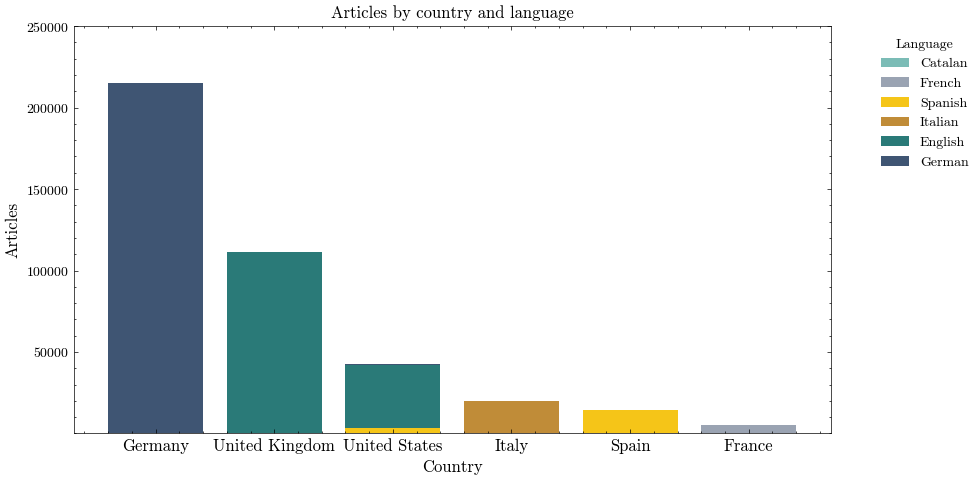

In [3]:
# articles per country and language
articles_per_country_lang = articles.groupby(['country', 'language']).size().unstack(fill_value=0)

# get rid of international articles
articles_per_country_lang = articles_per_country_lang.loc[articles_per_country_lang.index != 'int']

# Sort countries by total articles
articles_per_country_lang = articles_per_country_lang.loc[articles_per_country_lang.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 5))

# Create stacked bar plot
bottom = None
# Sort columns by sum to put bigger stacks on bottom
sorted_columns = articles_per_country_lang.sum().sort_values(ascending=True).index
for lang in sorted_columns:
    ax.bar(articles_per_country_lang.index, articles_per_country_lang[lang],
           bottom=bottom, color=colors.get(lang, '#000000'), label=labels[lang])
    bottom = articles_per_country_lang[lang] if bottom is None else bottom + articles_per_country_lang[lang]

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Articles', fontsize=12)
ax.title.set_text('Articles by country and language')

# Set country names and font size
ax.set_xticklabels(["Germany", "United Kingdom", "United States", "Italy", "Spain", "France"])
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)

# Hide 0 tick in y-axis except first one
ax.set_yticks(ax.get_yticks()[1:])

# Add legend
ax.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Save plots
plt.savefig('../figures/figs/articles_per_country.svg', bbox_inches='tight')
plt.savefig('../figures/figs/articles_per_country.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_1649897/1410448575.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["German", "English", "Spanish", "Italian", "French", "Catalan"], fontsize=12)


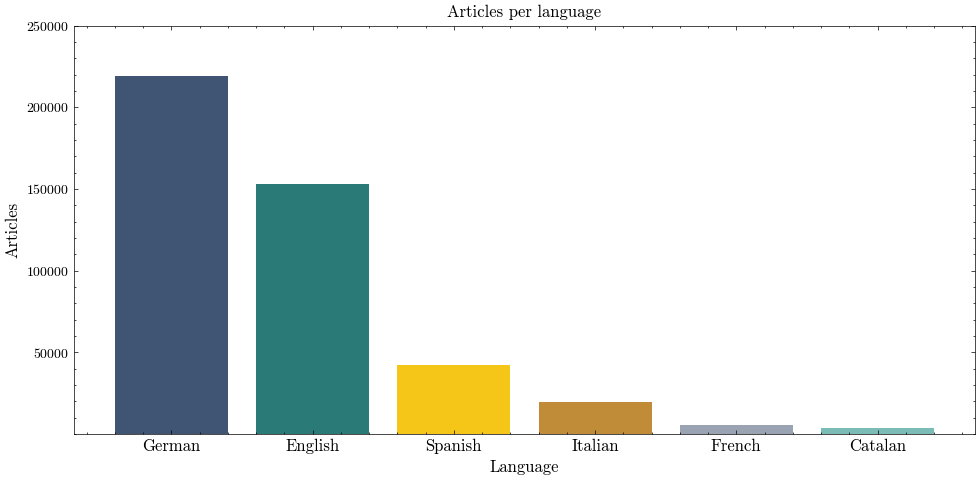

In [4]:
## by language
articles_per_language=articles.groupby('language').size()
articles_per_language=articles_per_language.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

# Create bar plot with language-specific colors
bar_colors = [colors[lang] for lang in articles_per_language.index]
ax.bar(articles_per_language.index, articles_per_language.values, color=bar_colors)

# finish it
ax.set_xlabel('Language', fontsize=12)
ax.set_ylabel('Articles', fontsize=12)
ax.title.set_text('Articles per language')

# x ticks should be German, English, Spanish, Italian, French, Catalan and be bigger
ax.set_xticklabels(["German", "English", "Spanish", "Italian", "French", "Catalan"], fontsize=12)

# hide 0 tick in the y axis
ax.set_yticks(ax.get_yticks()[1:])

plt.tight_layout()
plt.savefig('../figures/figs/articles_per_language.svg')
plt.savefig('../figures/figs/articles_per_language.png')
plt.show()

/tmp/ipykernel_1649897/3669393709.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["Germany", "United Kingdom", "United States", "Italy", "Spain", "France"])
/tmp/ipykernel_1649897/3669393709.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=10.5)
/tmp/ipykernel_1649897/3669393709.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), fontsize=10.5)


FileNotFoundError: [Errno 2] No such file or directory: 'figs/combined_plots.svg'

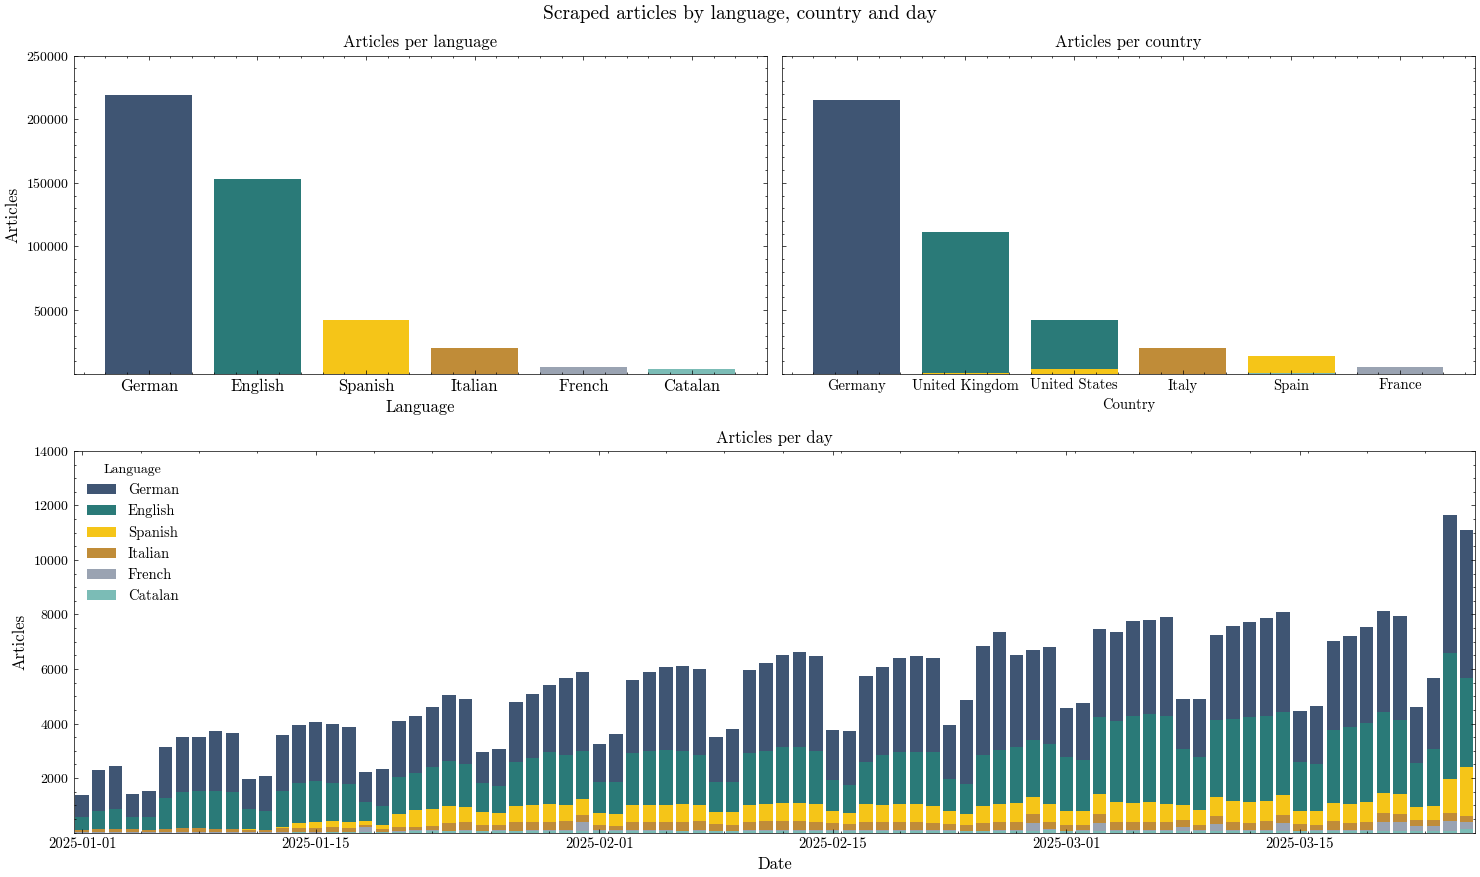

In [ ]:
## Combined plots
fig = plt.figure(figsize=(15, 9))

# Create a gridspec layout
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Language plot (top left)
ax1 = fig.add_subplot(gs[0, 0])
bar_colors = [colors[lang] for lang in articles_per_language.index]
ax1.bar(articles_per_language.index, articles_per_language.values, color=bar_colors)
ax1.set_xlabel('Language', fontsize=12)
ax1.set_ylabel('Articles', fontsize=12)
ax1.title.set_text('Articles per language')
ax1.set_xticks(range(len(articles_per_language.index)))
ax1.set_xticklabels(["German", "English", "Spanish", "Italian", "French", "Catalan"], fontsize=12)
# ax1.set_yticks(ax1.get_yticks()[1:])

# Country plot (top right) with stacked bars
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.tick_params(axis='y', labelleft=False)  # Hide y-axis labels for right plot

# get rid of international articles
articles_per_country_lang = articles.groupby(['country', 'language']).size().unstack(fill_value=0)
articles_per_country_lang = articles_per_country_lang.loc[articles_per_country_lang.index != 'int']

# Sort countries by total articles
articles_per_country_lang = articles_per_country_lang.loc[articles_per_country_lang.sum(axis=1).sort_values(ascending=False).index]

# Create stacked bar plot
bottom = None
# Sort columns by sum to put bigger stacks on bottom
sorted_columns = articles_per_country_lang.sum().sort_values(ascending=True).index
for lang in sorted_columns:
    ax2.bar(articles_per_country_lang.index, articles_per_country_lang[lang],
           bottom=bottom, color=colors.get(lang, '#000000'), label=labels[lang])
    bottom = articles_per_country_lang[lang] if bottom is None else bottom + articles_per_country_lang[lang]

ax2.set_xlabel('Country', fontsize=10.5)
# Only show y label on left plot
ax2.set_ylabel('')
ax2.title.set_text('Articles per country')

# Set country names and font size
ax2.set_xticklabels(["Germany", "United Kingdom", "United States", "Italy", "Spain", "France"])
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=10.5)

# Hide 0 tick in y-axis except first one
ax2.set_yticks(ax2.get_yticks()[1:])
# Day plot (bottom) with stacked bars
ax3 = fig.add_subplot(gs[1, :])
# Create stacked bar plot
bottom = None
# Sort columns by sum to put bigger stacks on bottom
sorted_columns = articles_by_date_lang.sum().sort_values(ascending=True).index
for lang in sorted_columns:
    ax3.bar(articles_by_date_lang.index, articles_by_date_lang[lang], 
           bottom=bottom, color=colors.get(lang, '#000000'), label=labels[lang])
    bottom = articles_by_date_lang[lang] if bottom is None else bottom + articles_by_date_lang[lang]

ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Articles', fontsize=12)
ax3.title.set_text('Articles per day')

# Set x-axis limits
plt.xlim(pd.Timestamp('2025-01-01')-pd.Timedelta(hours=12), 
         pd.Timestamp('2025-03-26')-pd.Timedelta(hours=12))


# Add legend to top left of bottom plot
# Sort legend handles and labels by total count
handles, labels = ax3.get_legend_handles_labels()
totals = [articles_by_date_lang[lang].sum() for lang in sorted_columns]
handles_labels = sorted(zip(handles, labels, totals), key=lambda x: x[2], reverse=True)
handles = [h[0] for h in handles_labels]
labels = [h[1] for h in handles_labels]
ax3.legend(handles, labels, title='Language', loc='upper left', fontsize=10.5)

# Hide 0 tick in y-axis except first one
ax3.set_yticks(ax3.get_yticks()[1:])

# make x ticks fontsize 10
ax3.set_xticklabels(ax3.get_xticklabels(), fontsize=10.5)

# title should be Scraped articles, by language, country and day
fig.suptitle('Scraped articles by language, country and day', fontsize=14)

plt.tight_layout()
plt.savefig('../figures/figs/combined_plots.svg', bbox_inches='tight')
plt.savefig('../figures/figs/combined_plots.png', bbox_inches='tight')

plt.show()

## Claims up to now

In [17]:
## claims in claims_examples and claims_naive that then have llama8b, llama70b, qwq32b
# Read each CSV and add method and llm columns
claims_naive = pd.read_csv('claims_naive_llama8b.csv')
claims_naive['method'] = 'naive'
claims_naive['llm'] = 'llama8b'

claims_examples = pd.read_csv('claims_examples_llama8b.csv')
claims_examples['method'] = 'examples'
claims_examples['llm'] = 'llama8b'

claims_naive_llama70b = pd.read_csv('claims_naive_llama70b.csv')
claims_naive_llama70b['method'] = 'naive'
claims_naive_llama70b['llm'] = 'llama70b'

claims_examples_llama70b = pd.read_csv('claims_examples_llama70b.csv')
claims_examples_llama70b['method'] = 'examples'
claims_examples_llama70b['llm'] = 'llama70b'

claims_naive_qwq32b = pd.read_csv('claims_naive_qwq32b.csv')
claims_naive_qwq32b['method'] = 'naive'
claims_naive_qwq32b['llm'] = 'qwq32b'

claims_examples_qwq32b = pd.read_csv('claims_examples_qwq32b.csv')
claims_examples_qwq32b['method'] = 'examples'
claims_examples_qwq32b['llm'] = 'qwq32b'

claims_generated = pd.concat([claims_naive, claims_examples, claims_naive_llama70b, claims_examples_llama70b, claims_naive_qwq32b, claims_examples_qwq32b])

In [18]:
claims_generated

,article_id,country,language,date,article_text,claim,is_factual,reasoning,method,llm,source
0,7,de,german,2025-03-01 06:45:00,Krankenhaus Geesthacht: Stärkere Kooperation m...,"On 2025-03-01, a news article was published an...",True,- I can generate claims from the context of me...,naive,llama8b,NaN
1,7,de,german,2025-03-01 06:45:00,Krankenhaus Geesthacht: Stärkere Kooperation m...,"On 2025-03-01, that on relevant county author...",True,- I can generate claims from the context of me...,naive,llama8b,NaN
2,8,de,german,2025-02-10 17:23:00.136000,Kultur in Parteiprogrammen - Vom Randthema bis...,En das Bündnis 90/die Grünen möchte Kultur als...,True,"- Die Plausibilität hängt davon ab, wie genau ...",naive,llama8b,NaN
3,8,de,german,2025-02-10 17:23:00.136000,Kultur in Parteiprogrammen - Vom Randthema bis...,Die Partei Die Linke hält Kultur von gesellsch...,True,"- Die Plausibilität hängt davon ab, wie genau ...",naive,llama8b,NaN
4,8,de,german,2025-02-10 17:23:00.136000,Kultur in Parteiprogrammen - Vom Randthema bis...,Dem BSW zufolge ist kulturelle Teilhabe Pflich...,True,"- Die Plausibilität hängt davon ab, wie genau ...",naive,llama8b,NaN
...,...,...,...,...,...,...,...,...,...,...,...
929,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"Between September 2022 and January 2023, Toni ...",True,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
930,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"On January 25, 2023, an integrity meeting orga...",True,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
931,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"As of 2023-02-13, Toni Cole received a 3-month...",False,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
932,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"From January 2022 to December 2023, Toni Cole ...",False,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard


In [20]:
# save claims_generated
claims_generated.to_csv('claims_generated.csv', index=False)

In [23]:
claims_generated

,article_id,country,language,date,article_text,claim,is_factual,reasoning,method,llm,source
0,7,de,german,2025-03-01 06:45:00,Krankenhaus Geesthacht: Stärkere Kooperation m...,"On 2025-03-01, a news article was published an...",True,- I can generate claims from the context of me...,naive,llama8b,NaN
1,7,de,german,2025-03-01 06:45:00,Krankenhaus Geesthacht: Stärkere Kooperation m...,"On 2025-03-01, that on relevant county author...",True,- I can generate claims from the context of me...,naive,llama8b,NaN
2,8,de,german,2025-02-10 17:23:00.136000,Kultur in Parteiprogrammen - Vom Randthema bis...,En das Bündnis 90/die Grünen möchte Kultur als...,True,"- Die Plausibilität hängt davon ab, wie genau ...",naive,llama8b,NaN
3,8,de,german,2025-02-10 17:23:00.136000,Kultur in Parteiprogrammen - Vom Randthema bis...,Die Partei Die Linke hält Kultur von gesellsch...,True,"- Die Plausibilität hängt davon ab, wie genau ...",naive,llama8b,NaN
4,8,de,german,2025-02-10 17:23:00.136000,Kultur in Parteiprogrammen - Vom Randthema bis...,Dem BSW zufolge ist kulturelle Teilhabe Pflich...,True,"- Die Plausibilität hängt davon ab, wie genau ...",naive,llama8b,NaN
...,...,...,...,...,...,...,...,...,...,...,...
929,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"Between September 2022 and January 2023, Toni ...",True,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
930,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"On January 25, 2023, an integrity meeting orga...",True,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
931,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"As of 2023-02-13, Toni Cole received a 3-month...",False,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
932,116,uk,english,2025-02-20 12:32:42,Female prison officer who kissed inmate and se...,"From January 2022 to December 2023, Toni Cole ...",False,"For factual claims, the article provides clear...",examples,qwq32b,Evening Standard
